In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from memmap_replay_buffer import ReplayBuffer

TRAJ_DIR = Path("miniboss-easy-100seeds-100K")

ACTION_NAMES = {
    0: "left",
    1: "right",
    2: "forward",
    3: "pickup",
    4: "drop",
    5: "toggle",
    6: "done",
}

rb = ReplayBuffer.from_folder(TRAJ_DIR)
seeds = np.load(TRAJ_DIR / "seeds.npy")

print(f"Trajectory dir : {TRAJ_DIR}")
print(f"Num episodes   : {rb.num_episodes}")
print(f"Max episodes   : {rb.max_episodes}")
print(f"Max timesteps  : {rb.max_timesteps}")
print(f"State shape    : {rb.shapes['state']}")
print(f"Seeds          : {seeds}")

Trajectory dir : trajectories/miniboss-medium-3seeds-30K
Num episodes   : 16707
Max episodes   : 35000
Max timesteps  : 100
State shape    : (56, 56, 3)
Seeds          : [ 5  6  8  9 10]


In [2]:
# Load a large batch to compute statistics
STAT_BATCH = min(rb.num_episodes, 4096)
dl = rb.dataloader(batch_size=STAT_BATCH)
batch = next(iter(dl))

states = batch["state"].numpy()        # (B, T, 7, 7, 3)
actions = batch["action"].numpy()      # (B, T)
lens = batch["_lens"].numpy()          # (B,)
mission_emb = batch["mission_embedding"].numpy()  # (B, 384)

print(f"Loaded batch: {STAT_BATCH} episodes")
print(f"State range  : [{states.min():.0f}, {states.max():.0f}]")
print(f"Action range : [{actions.min():.0f}, {actions.max():.0f}]")
print(f"Ep lengths   : min={lens.min()}, max={lens.max()}, mean={lens.mean():.1f}, median={np.median(lens):.1f}")

Loaded batch: 4096 episodes
State range  : [0, 255]
Action range : [0, 6]
Ep lengths   : min=16, max=79, mean=39.0, median=36.0


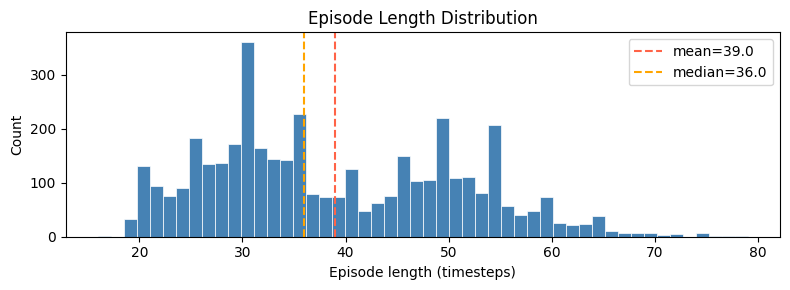

In [3]:
# --- Episode length distribution ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lens, bins=50, edgecolor="white", linewidth=0.5, color="steelblue")
ax.axvline(lens.mean(), color="tomato", ls="--", label=f"mean={lens.mean():.1f}")
ax.axvline(np.median(lens), color="orange", ls="--", label=f"median={np.median(lens):.1f}")
ax.set_xlabel("Episode length (timesteps)")
ax.set_ylabel("Count")
ax.set_title("Episode Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

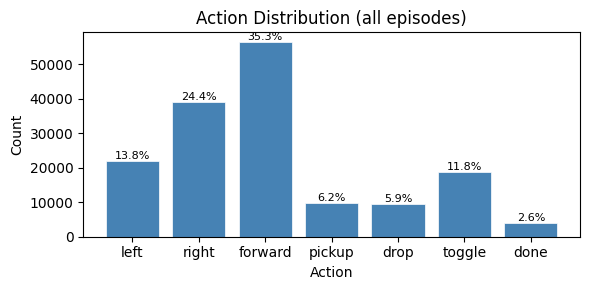

In [4]:
# --- Action distribution ---
all_actions = []
for i in range(len(lens)):
    all_actions.append(actions[i, :lens[i]])
all_actions = np.concatenate(all_actions).astype(int)

unique_acts, counts = np.unique(all_actions, return_counts=True)
labels = [ACTION_NAMES.get(a, str(a)) for a in unique_acts]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(labels, counts, color="steelblue", edgecolor="white", linewidth=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{c/len(all_actions)*100:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Action")
ax.set_ylabel("Count")
ax.set_title("Action Distribution (all episodes)")
plt.tight_layout()
plt.show()

In [5]:
def render_frame(frame, scale=12):
    """Upscale a tiny (7,7,3) frame for display via nearest-neighbor."""
    img = frame.astype(np.uint8)
    return np.kron(img, np.ones((scale, scale, 1))).astype(np.uint8)


def show_trajectory(states, actions, ep_len, ep_idx, max_frames=20, scale=12):
    """Display frames from a single trajectory in a grid."""
    n = min(ep_len, max_frames)
    step = max(1, ep_len // n)
    indices = list(range(0, ep_len, step))[:n]

    fig, axes = plt.subplots(1, len(indices), figsize=(2 * len(indices), 2.5))
    if len(indices) == 1:
        axes = [axes]
    for ax, t in zip(axes, indices):
        ax.imshow(render_frame(states[t], scale=scale))
        act = int(actions[t])
        ax.set_title(f"t={t}\n{ACTION_NAMES.get(act, act)}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"Episode {ep_idx}  (len={ep_len})", fontsize=11)
    plt.tight_layout()
    plt.show()

max: 255.0
tensor: [[[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
  

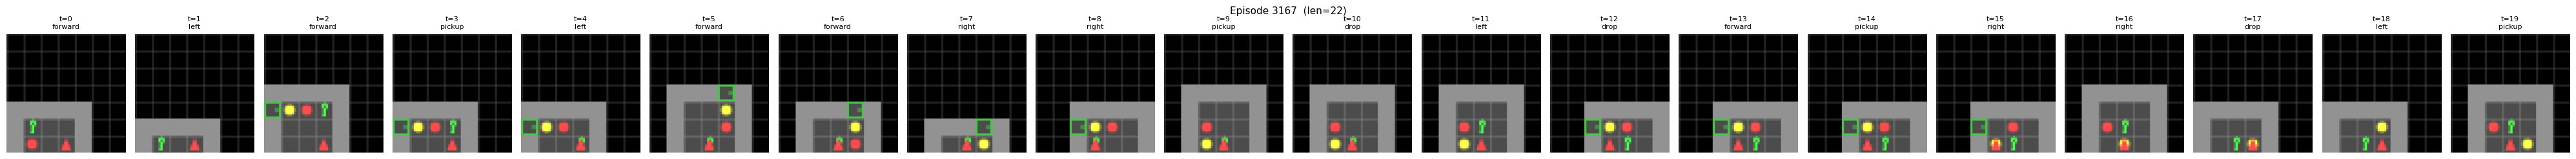

max: 255.0
tensor: [[[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
  

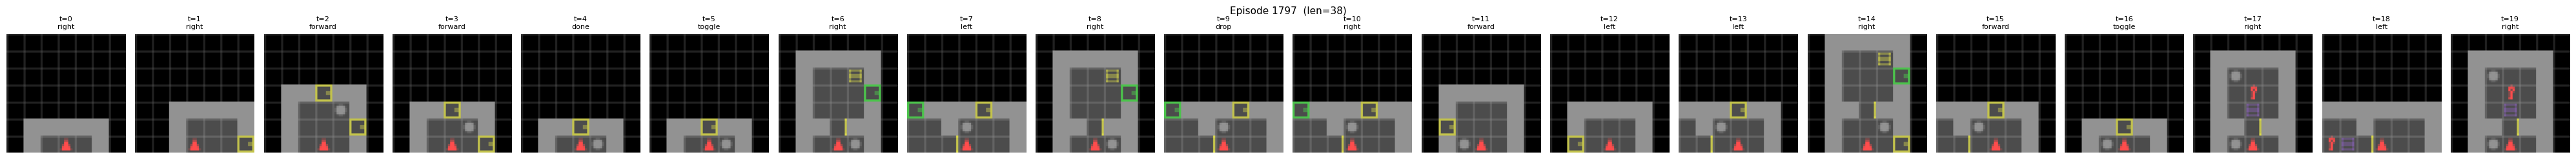

max: 255.0
tensor: [[[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
  

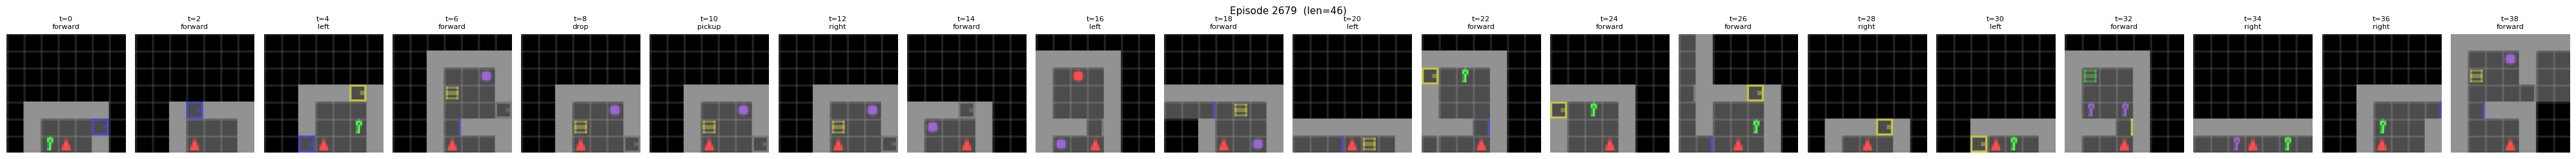

max: 255.0
tensor: [[[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
  

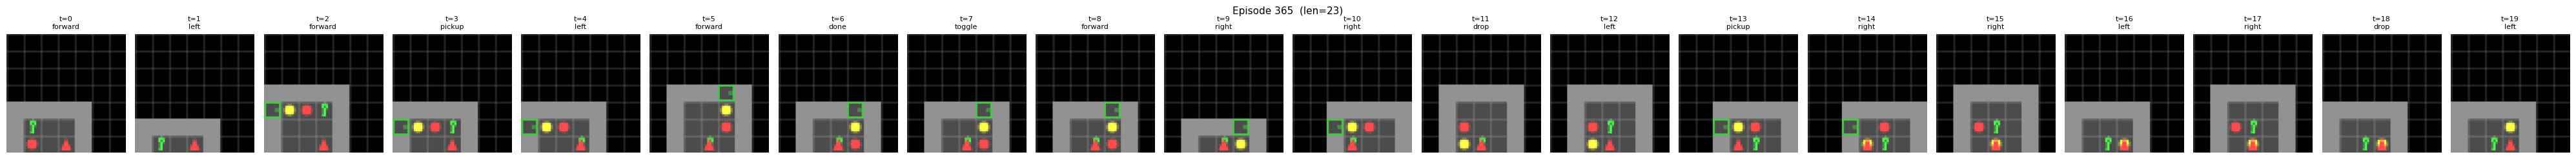

max: 255.0
tensor: [[[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[146. 146. 146.]
   [146. 146. 146.]
   [146. 146. 146.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[ 55.  55.  55.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   ...
   [ 33.  33.  33.]
   [ 33.  33.  33.]
   [ 33.  33.  33.]]

  [[ 33.  33.  33.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
  

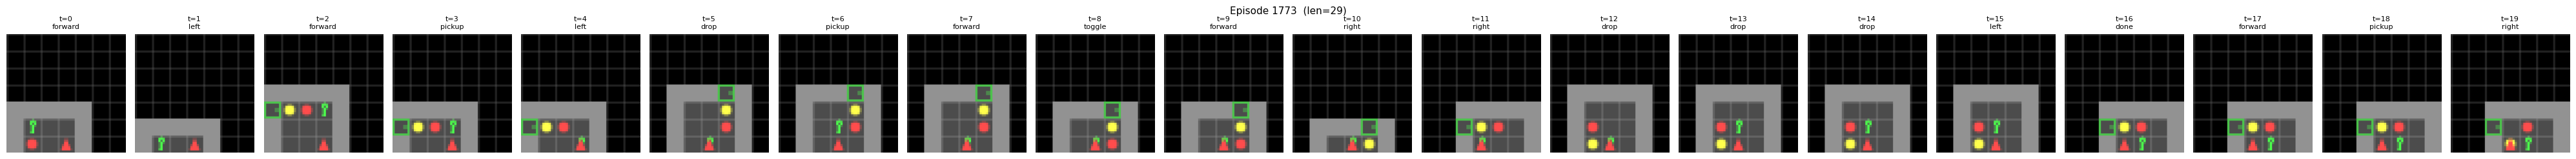

In [6]:
# --- Show a few sample trajectories ---
rng = np.random.default_rng(42)
sample_ids = rng.choice(len(lens), size=min(5, len(lens)), replace=False)

for idx in sample_ids:
    print(f"max: {states[idx].max()}")
    print(f"tensor: {states[idx]}")
    show_trajectory(states[idx], actions[idx], int(lens[idx]), ep_idx=idx)

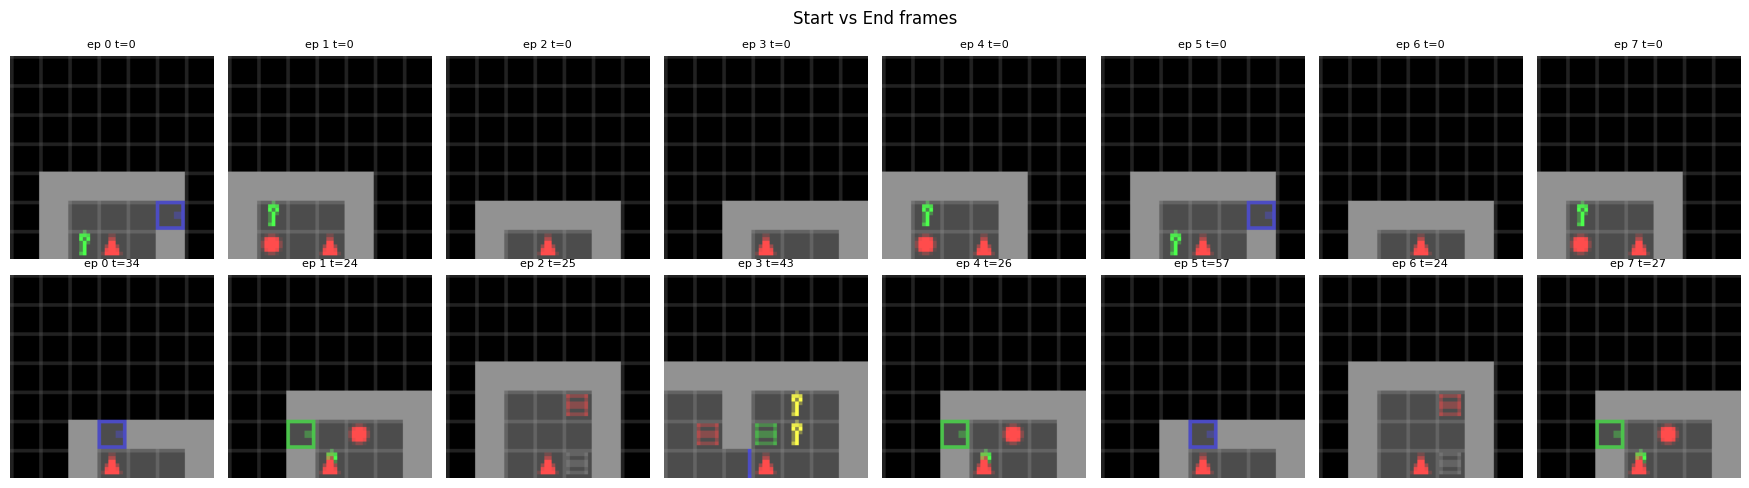

In [7]:
# --- First & last frame comparison for several episodes ---
n_show = min(8, len(lens))
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 5))
if n_show == 1:
    axes = axes.reshape(2, 1)

for col in range(n_show):
    ep_len = int(lens[col])
    axes[0, col].imshow(render_frame(states[col, 0]))
    axes[0, col].set_title(f"ep {col} t=0", fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(render_frame(states[col, ep_len - 1]))
    axes[1, col].set_title(f"ep {col} t={ep_len-1}", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Start", fontsize=10)
axes[1, 0].set_ylabel("End", fontsize=10)
fig.suptitle("Start vs End frames", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3202047/1559044286.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(ACTION_NAMES))


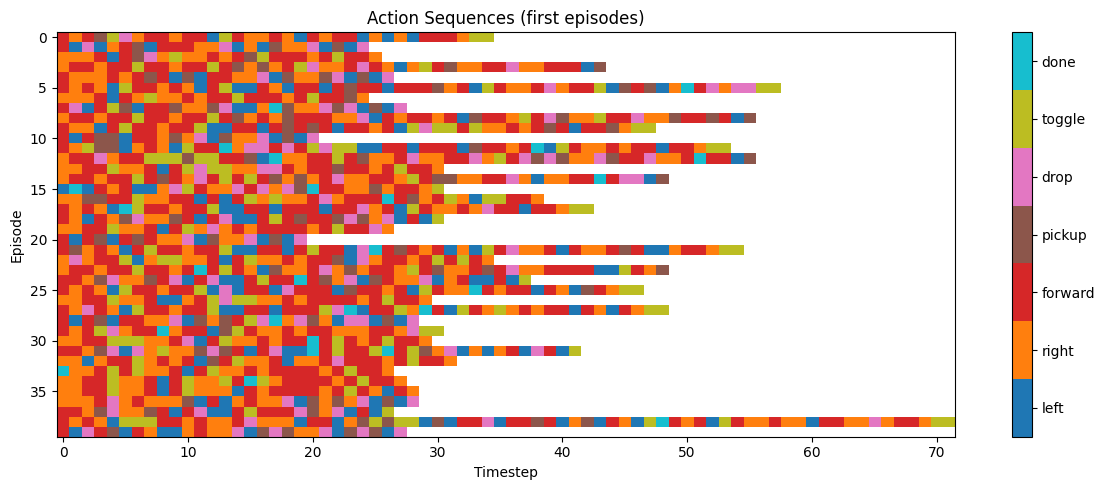

In [8]:
# --- Action sequence heatmap for first N episodes ---
N_HEAT = min(40, len(lens))
max_t = int(lens[:N_HEAT].max())
action_grid = np.full((N_HEAT, max_t), np.nan)
for i in range(N_HEAT):
    l = int(lens[i])
    action_grid[i, :l] = actions[i, :l]

fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.get_cmap("tab10", len(ACTION_NAMES))
im = ax.imshow(action_grid, aspect="auto", cmap=cmap, vmin=-0.5, vmax=len(ACTION_NAMES) - 0.5, interpolation="nearest")
cbar = fig.colorbar(im, ax=ax, ticks=list(ACTION_NAMES.keys()))
cbar.ax.set_yticklabels([ACTION_NAMES[k] for k in ACTION_NAMES])
ax.set_xlabel("Timestep")
ax.set_ylabel("Episode")
ax.set_title("Action Sequences (first episodes)")
plt.tight_layout()
plt.show()

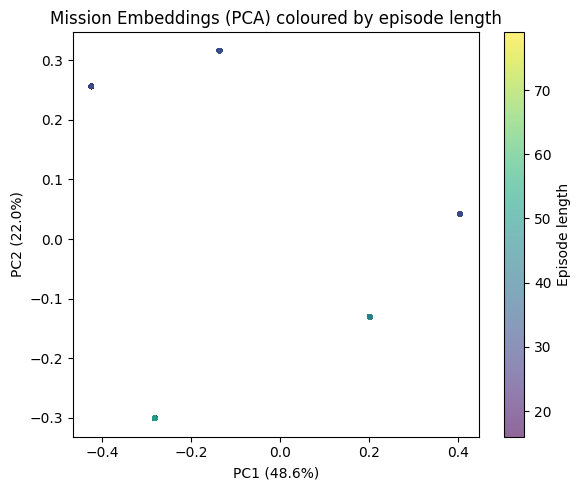

In [9]:
# --- Mission embedding PCA (2D) ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(mission_emb)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=lens, cmap="viridis", s=8, alpha=0.6)
fig.colorbar(sc, ax=ax, label="Episode length")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Mission Embeddings (PCA) coloured by episode length")
plt.tight_layout()
plt.show()